## Predicting the winner of the Australian GP 2026

In [2]:
!pip install fastf1

import fastf1.plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import os 

In [3]:
os.makedirs('cache/', exist_ok=True)
fastf1.Cache.enable_cache('cache/')
fastf1.plotting.setup_mpl(color_scheme='fastf1')

In [4]:
fp1 = fastf1.get_session(2026, 'Australia', 'FP1')
fp2 = fastf1.get_session(2026, 'Australia', 'FP2')
fp3 = fastf1.get_session(2026, 'Australia', 'FP3')
quali = fastf1.get_session(2026, 'Australia', 'Q')

fp1.load()
fp2.load()
fp3.load()
quali.load()

core           INFO 	Loading data for Australian Grand Prix - Practice 1 [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 14
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 14)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 

In [19]:
for session, name in [(fp1,'FP1'), (fp2,'FP2'), (fp3,'FP3')]:
    fastest = session.laps.pick_quicklaps().groupby('Driver')['LapTime'].min().sort_values()
    print(f"\n{name} Fastest Laps:")
    print(fastest)


FP1 Fastest Laps:
Driver
LEC   0 days 00:01:20.267000
HAM   0 days 00:01:20.736000
VER   0 days 00:01:20.789000
HAD   0 days 00:01:21.087000
LIN   0 days 00:01:21.313000
PIA   0 days 00:01:21.342000
RUS   0 days 00:01:21.371000
ANT   0 days 00:01:21.376000
BOR   0 days 00:01:21.696000
HUL   0 days 00:01:21.969000
OCO   0 days 00:01:22.161000
SAI   0 days 00:01:22.323000
LAW   0 days 00:01:22.613000
BEA   0 days 00:01:22.682000
ALB   0 days 00:01:23.130000
COL   0 days 00:01:23.325000
BOT   0 days 00:01:24.022000
GAS   0 days 00:01:24.035000
NOR   0 days 00:01:24.391000
PER   0 days 00:01:24.620000
Name: LapTime, dtype: timedelta64[ns]

FP2 Fastest Laps:
Driver
PIA   0 days 00:01:19.729000
ANT   0 days 00:01:19.943000
RUS   0 days 00:01:20.049000
HAM   0 days 00:01:20.050000
LEC   0 days 00:01:20.291000
VER   0 days 00:01:20.366000
NOR   0 days 00:01:20.794000
LIN   0 days 00:01:20.922000
HAD   0 days 00:01:20.941000
OCO   0 days 00:01:21.179000
BEA   0 days 00:01:21.326000
HUL   0 day

req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for driver_info


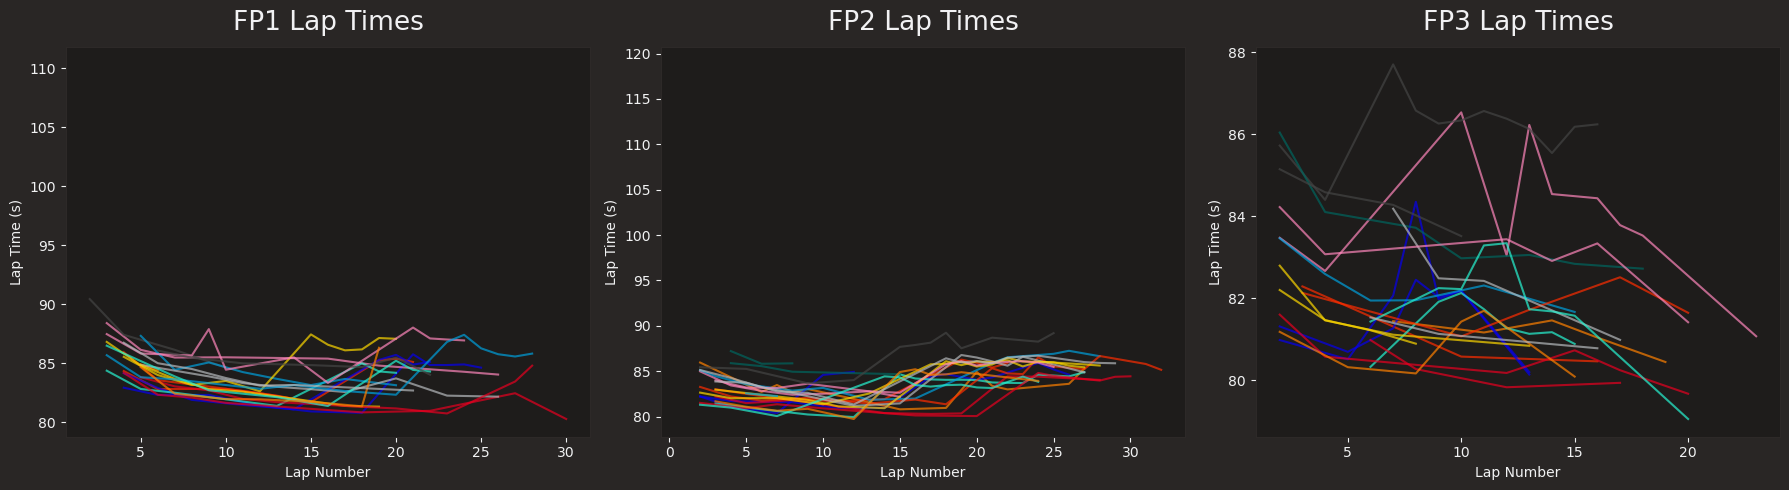

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (session, name) in zip(axes, [(fp1,'FP1'), (fp2,'FP2'), (fp3,'FP3')]):
    for driver in session.laps['Driver'].unique():
        driver_laps = session.laps.pick_drivers(driver).pick_quicklaps()
        color = fastf1.plotting.get_driver_color(driver, session=session)
        ax.plot(driver_laps['LapNumber'],
                driver_laps['LapTime'].dt.total_seconds(),
                color=color, alpha=0.7, label=driver)
    ax.set_title(f'{name} Lap Times')
    ax.set_xlabel('Lap Number')
    ax.set_ylabel('Lap Time (s)')

plt.tight_layout()
plt.show()

req            INFO 	Using cached data for driver_info


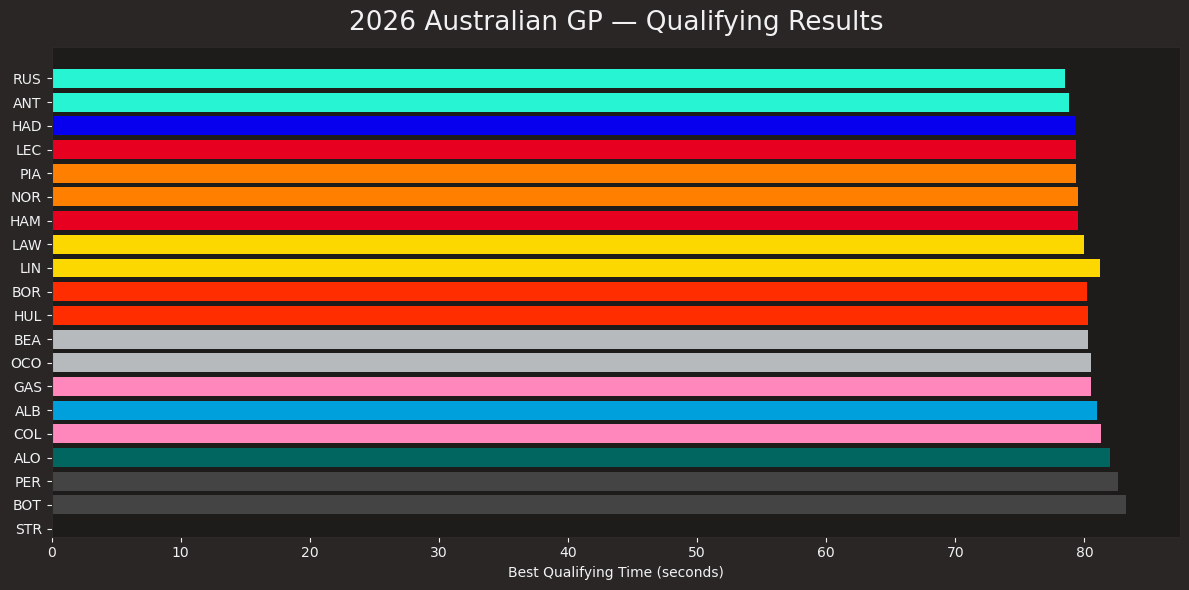

In [21]:
quali_results = quali.results[['Abbreviation', 'TeamName', 'Position', 'Q1', 'Q2', 'Q3']].copy()
quali_results['BestTime'] = quali_results['Q3'].fillna(
    quali_results['Q2']).fillna(quali_results['Q1'])
quali_results['BestTimeSec'] = quali_results['BestTime'].dt.total_seconds()
quali_results = quali_results.sort_values('Position')

plt.figure(figsize=(12, 6))
colors = [fastf1.plotting.get_driver_color(d, session=quali)
          for d in quali_results['Abbreviation']]
plt.barh(quali_results['Abbreviation'][::-1],
         quali_results['BestTimeSec'][::-1], color=colors[::-1])
plt.xlabel('Best Qualifying Time (seconds)')
plt.title('2026 Australian GP — Qualifying Results')
plt.tight_layout()
plt.show()

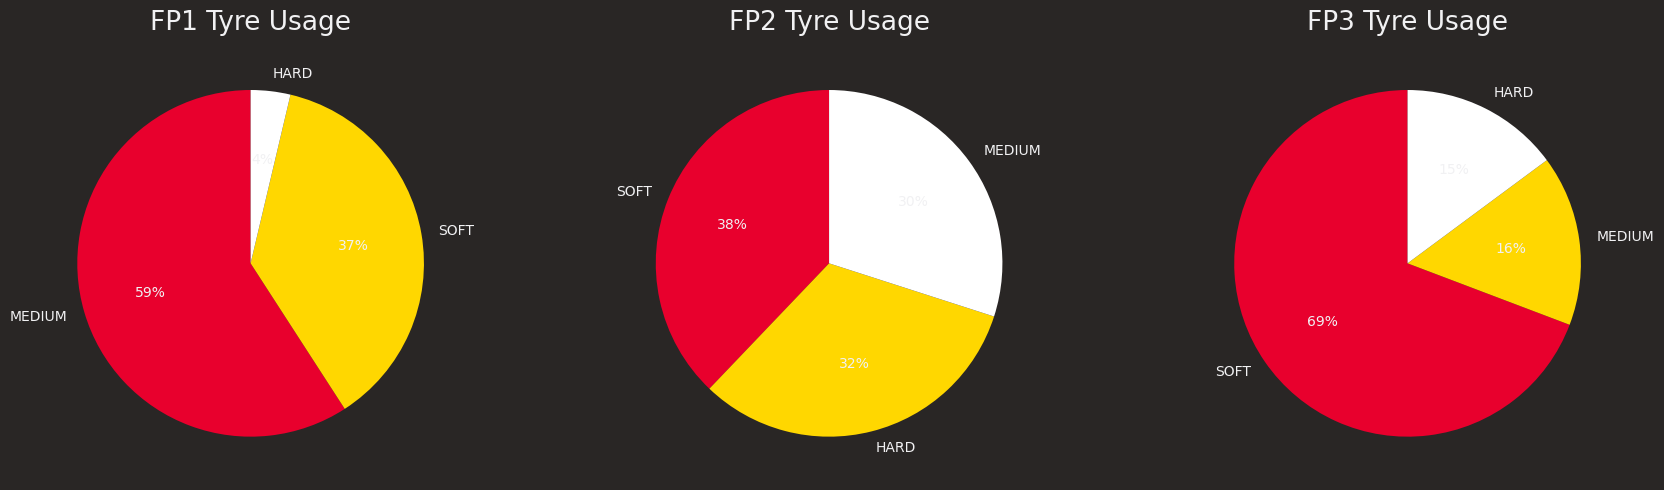

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (session, name) in zip(axes, [(fp1,'FP1'), (fp2,'FP2'), (fp3,'FP3')]):
    compound_counts = session.laps['Compound'].value_counts()
    ax.pie(compound_counts, labels=compound_counts.index,
           colors=['#e8002d','#ffd700','#ffffff'],
           autopct='%1.0f%%', startangle=90)
    ax.set_title(f'{name} Tyre Usage')

plt.tight_layout()
plt.show()

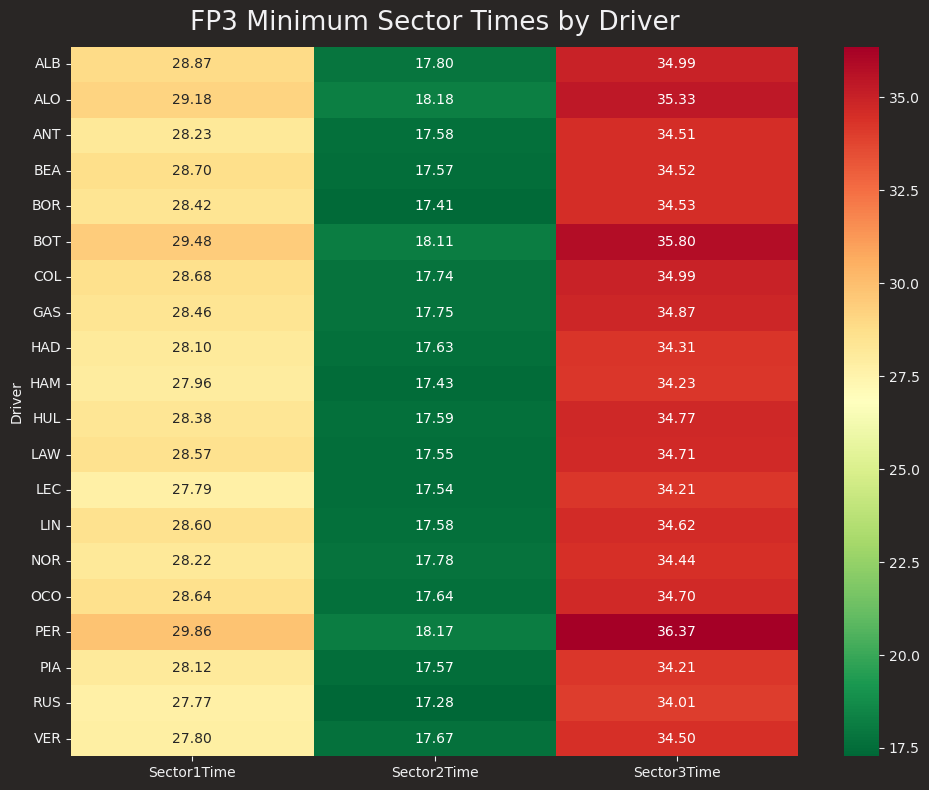

In [23]:
sector_times = fp3.laps.pick_quicklaps().groupby('Driver')[
    ['Sector1Time','Sector2Time','Sector3Time']
].min().apply(lambda x: x.dt.total_seconds())

plt.figure(figsize=(10, 8))
sns.heatmap(sector_times, annot=True, fmt='.2f', cmap='RdYlGn_r')
plt.title('FP3 Minimum Sector Times by Driver')
plt.tight_layout()
plt.show()

In [24]:
def get_fastest(session, label):
    fastest = (session.laps
               .pick_quicklaps()
               .groupby('Driver')['LapTime']
               .min()
               .dt.total_seconds()
               .reset_index()
               .rename(columns={'LapTime': f'fastest_{label}'}))
    return fastest

fp1_fast = get_fastest(fp1, 'fp1')
fp2_fast = get_fastest(fp2, 'fp2')
fp3_fast = get_fastest(fp3, 'fp3')

quali_clean = quali.results[['Abbreviation','TeamName','Position']].copy()
quali_clean.columns = ['Driver','TeamName','GridPosition']
quali_clean['GridPosition'] = pd.to_numeric(quali_clean['GridPosition'], errors='coerce')

df = quali_clean.copy()
df = df.merge(fp1_fast, on='Driver', how='left')
df = df.merge(fp2_fast, on='Driver', how='left')
df = df.merge(fp3_fast, on='Driver', how='left')

print(df.isnull().sum())
df = df.dropna()
print(f"\nClean dataset: {df.shape[0]} drivers × {df.shape[1]} columns")
print(df)

Driver          0
TeamName        0
GridPosition    3
fastest_fp1     2
fastest_fp2     2
fastest_fp3     2
dtype: int64

Clean dataset: 17 drivers × 6 columns
   Driver         TeamName  GridPosition  fastest_fp1  fastest_fp2  \
0     RUS         Mercedes           1.0       81.371       80.049   
1     ANT         Mercedes           2.0       81.376       79.943   
2     HAD  Red Bull Racing           3.0       81.087       80.941   
3     LEC          Ferrari           4.0       80.267       80.291   
4     PIA          McLaren           5.0       81.342       79.729   
5     NOR          McLaren           6.0       84.391       80.794   
6     HAM          Ferrari           7.0       80.736       80.050   
7     LAW     Racing Bulls           8.0       82.613       81.358   
8     LIN     Racing Bulls           9.0       81.313       80.922   
9     BOR             Audi          10.0       81.696       81.668   
10    HUL             Audi          11.0       81.969       81.351   


In [25]:
pole_time = df['GridPosition'].eq(1)
pole_fp3 = df.loc[df['GridPosition'] == 1, 'fastest_fp3'].values[0]
df['gap_to_pole_fp3'] = df['fastest_fp3'] - pole_fp3

df['practice_avg'] = df[['fastest_fp1','fastest_fp2','fastest_fp3']].mean(axis=1)

df['fp2_fp3_improvement'] = df['fastest_fp3'] - df['fastest_fp2']

print(df[['Driver','GridPosition','gap_to_pole_fp3','practice_avg','fp2_fp3_improvement']])

   Driver  GridPosition  gap_to_pole_fp3  practice_avg  fp2_fp3_improvement
0     RUS           1.0            0.000     80.157667               -0.996
1     ANT           2.0            1.271     80.547667                0.381
2     HAD           3.0            1.084     80.721667               -0.804
3     LEC           4.0            0.774     80.128333               -0.464
4     PIA           5.0            1.034     80.386000                0.358
5     NOR           6.0            1.390     81.876000               -0.351
6     HAM           7.0            0.616     80.151667               -0.381
7     LAW           8.0            1.837     81.620333               -0.468
8     LIN           9.0            1.785     81.024333               -0.084
9     BOR          10.0            1.406     81.274333               -1.209
10    HUL          11.0            2.014     81.462333               -0.284
11    BEA          12.0            1.725     81.595333               -0.548
12    OCO   

In [31]:
!pip install xgboost --quiet
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder

model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X, y)

df['PredictedScore'] = model.predict(X)
df['PredictedPosition'] = df['PredictedScore'].rank().astype(int)
df_pred = df.sort_values('PredictedPosition')

winner = df_pred.iloc[0]
print(f"🏆 Predicted Winner: {winner['Driver']} ({winner['TeamName']})")

6136.77s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
🏆 Predicted Winner: RUS (Mercedes)
